# The near-field / far-field wake model — derivation and residual error

The induced voltage of a bunch is the convolution of its line density
$\lambda$ (in C/s) with the point-charge wake $W$ (in V/C),

$$V(t) \;=\; \int_{-\infty}^{\infty} W(t - t')\,\lambda(t')\,\mathrm{d}t' ,$$

a smooth integral. The tracking code holds neither smooth function: the bunch
is a histogram — charges $q_j$ in bins of width $\Delta t$ centred at $t_j$ —
and the voltage is wanted as one number $V_i$ per bin.

## Why this model, and not another

**Why a recursive time-domain solver at all.** The frequency-domain solver
(`PeriodicFreqSolver`) gets an under-resolved resonator right by
construction — it evaluates $Z$ only below the profile's Nyquist frequency,
so there is nothing to alias — but it transforms a whole padded profile
every call. A wake that survives from one turn to the next, or a multi-bunch
profile that is mostly gaps, makes that expensive: the FFT must span the
full revolution period, empty bins included, every turn. A pole-residue
recursion instead carries the entire wake history in **one complex number
per pole** and costs one multiply-add per filled bin and pole; memory across
turns and across gaps comes for free. (Per-particle schemes such as the
MuSiC recursion sidestep the histogram entirely, but pay per macroparticle
and do not compose with the profile-based impedance chain.) The open
question is what kernel to feed the recursion.

**Why the kernel is bin-averaged — and why over three boxes.** The naive
kernel, the wake point-sampled at the bin centres, is what made the time-
and frequency-domain solvers disagree for low-$Q$ resonators in the first
place. The mechanism (section 3): a discrete convolution applies the
impedance folded over all alias images $f + m/\Delta t$, and point sampling
suppresses none of them — a resonance far above the Nyquist frequency folds
straight back onto the bunch's own spectrum. Averaging the wake over $k$
boxes of one bin width suppresses image $m$ by
$\operatorname{sinc}^k(f\Delta t + m)$, and choosing $k$ is a short ladder:

* $k = 2$ — one box for the source bin, one for the observation bin — is the
  *exact* voltage of a staircase beam, but its $|m|^{-2}$ tail still folds
  the images' **resistive** part into a band where the true impedance is
  reactive. That fabricates energy loss: up to a factor 14 in the loss
  factor at coarse binning (section 3).
* $k = 3$ — equivalently, reconstructing the line density as piecewise
  *linear* through the bin centres instead of as a staircase — suppresses
  the tail as $|m|^{-3}$, which holds the loss factor to a few per cent at
  the coarsest binning tried and makes it exact at ordinary ones.
* $k = 4$ changes nothing measurable further, and damps the physical band
  more.

The kernel is therefore $\overline W = W \ast B_2$ with the triple box
$B_2 = \mathrm{box} \ast \mathrm{box} \ast \mathrm{box}$: the cheapest
average that kills the alias leak. Its price — one non-causal tap and an
in-band damping that is second order in the bin width — is quantified in
section 7.

**Why a near/far split, and not something simpler.** Two shortcuts suggest
themselves; both fail. Smoothing the *charge* with fixed weights
($\tfrac18, \tfrac34, \tfrac18$) and feeding the raw exponential wake to the
recursion cannot reproduce $\overline W$: the exact kernel's bin-average
factor $\left(\frac{e^{p\Delta t}-1}{p\Delta t}\right)^{3}$ is
transcendental in $p\Delta t$, which no pole-independent weighting matches
once the pole is under-resolved ($|p\Delta t| \gtrsim 1$ — precisely the
regime being fixed). And no rearrangement of the recursion itself — exact
ODE stepping (first-order-hold / ramp-invariant discretisations),
re-weighted injection — helps either: a one-state linear recursion produces a pure
exponential in the lag plus at most one free tap (the direct
feed-through a first-order-hold discretisation supplies) — one
degree of freedom where three are needed, since sections 4–6 show
the exact kernel leaves the exponential family at the three lags
nearest the charge, where the averaging window straddles the wake's causal onset. Those
three values must be paid explicitly; everywhere else the recursion is
exact, so the split costs three multiply-adds per bin and nothing in
accuracy.

`MultiPoleSparseSolve` therefore evaluates the discretised integral in two
parts:

* the **far field** — one complex state per impedance pole, advanced by one
  multiply-add per bin, whose state deliberately *lags* the observed bin by
  two bins, and
* the **near field** — three closed-form taps covering source charge within
  $\pm\tfrac{3}{2}\Delta t$ of the observed bin: the previous bin, the bin
  itself, and the next one.

This note derives both parts from the integral above, shows why the split is
forced by the mathematics rather than chosen for convenience, and quantifies
the residual error of the discrete model. Each derivation step is verified,
symbolically (sympy) or numerically, in the cell that follows it.

**Conventions.** Fourier/Laplace: $Z(f) = \int W(\tau)\, e^{-2\pi i f \tau}
\mathrm{d}\tau$ and $s = i\omega = 2\pi i f$, so that $Z(f_r) = R_s$ for a
resonator. BLonD's solvers multiply the convolution by the (negative) beam
charge so that a resistive impedance decelerates the beam; that prefactor is
set to one here and we work with the kernel itself. Quality factors satisfy
$Q > \tfrac12$ (enforced by `Resonators`). SI units throughout.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import erf

plt.rcParams["figure.figsize"] = (9.0, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. The resonator wake as a sum of causal exponentials

A parallel RLC resonator (shunt impedance $R_s$, resonant frequency
$\omega_r = 2\pi f_r$, quality factor $Q$) has the impedance

$$Z(f) \;=\; \frac{R_s}{1 + iQ\left(\frac{f}{f_r} - \frac{f_r}{f}\right)}
\;=\; \left.\frac{\frac{\omega_r}{Q} R_s\, s}
{s^2 + \frac{\omega_r}{Q}\, s + \omega_r^2}\right|_{s = 2\pi i f} .$$

The denominator factorises over a complex-conjugate pole pair,

$$s^2 + \tfrac{\omega_r}{Q} s + \omega_r^2 = (s - p)(s - p^*), \qquad
p = -\alpha + i\bar\omega, \qquad
\alpha = \frac{\omega_r}{2Q}, \qquad
\bar\omega = \sqrt{\omega_r^2 - \alpha^2},$$

and partial fractions give

$$Z(s) = \frac{\rho}{s - p} + \frac{\rho^*}{s - p^*}, \qquad
\rho = R_s\,\alpha\left(1 + i\,\frac{\alpha}{\bar\omega}\right).$$

Each simple pole transforms back to a causal exponential, so the wake is

$$W(\tau) \;=\; 2\operatorname{Re}\!\left[\rho\, e^{p\tau}\right]\Theta(\tau)
\;=\; \frac{\omega_r R_s}{Q}\, e^{-\alpha\tau}
\left(\cos\bar\omega\tau - \frac{\alpha}{\bar\omega}\sin\bar\omega\tau\right)
\Theta(\tau) . \tag{1.1}$$

At $\tau = 0$ exactly, the source particle sees half the jump,
$W(0) = R_s\,\alpha$ — the fundamental theorem of beam loading; in (1.1) this is the
convention $\Theta(0) = \tfrac12$. The
*bin-averaged* kernel derived below integrates over $\tau$, so the single
point $\tau = 0$ carries no weight and no half-value convention will be
needed.

Two remarks that carry through the rest:

* Nothing is resonator-specific. Vector fitting (`fit_poles`,
  `Resonators.get_vectorfit`) writes *any* impedance as a sum of pole/residue
  pairs, so it suffices to treat one pole; the sum over poles is restored at
  the end. A **real** pole ($\operatorname{Im} p = 0$, produced only by
  vector fits) has no conjugate partner and enters without the factor 2.
* $Q > \tfrac12$ keeps $\bar\omega > 0$; at $Q = \tfrac12$ the pole pair
  degenerates and the formulas below divide by $\bar\omega$.

In [2]:
# Symbolic check of section 1: the residue and the wake.
s = sp.symbols("s")
R_s, alpha, omega_bar, tau = sp.symbols(
    "R_s alpha omega_bar tau", positive=True
)
# omega_r / Q = 2 alpha  and  omega_r**2 = alpha**2 + omega_bar**2:
p = -alpha + sp.I * omega_bar
Z = 2 * alpha * R_s * s / ((s - p) * (s - sp.conjugate(p)))

print("denominator:", sp.expand((s - p) * (s - sp.conjugate(p))))

rho = sp.simplify(sp.cancel((s - p) * Z).subs(s, p))
rho_claim = R_s * alpha * (1 + sp.I * alpha / omega_bar)
print(
    "rho - R_s alpha (1 + i alpha / omega_bar):",
    sp.simplify(sp.expand(rho - rho_claim)),
)

# (1.1): note omega_r R_s / Q = 2 R_s alpha.
wake_poles = 2 * sp.re(
    sp.expand((rho_claim * sp.exp(p * tau)).rewrite(sp.cos))
)
wake_textbook = (
    2
    * R_s
    * alpha
    * sp.exp(-alpha * tau)
    * (sp.cos(omega_bar * tau) - alpha / omega_bar * sp.sin(omega_bar * tau))
)
print(
    "2 Re[rho e^(p tau)] - textbook wake:",
    sp.simplify(sp.expand_trig(sp.simplify(wake_poles - wake_textbook))),
)

denominator: alpha**2 + 2*alpha*s + omega_bar**2 + s**2
rho - R_s alpha (1 + i alpha / omega_bar): 0


2 Re[rho e^(p tau)] - textbook wake: 0


## 2. Discretising the integral: a tent for the source, a box for the readout

The data are bin charges,
$q_j = \int_{t_j - \Delta t/2}^{t_j + \Delta t/2} \lambda(t')\,\mathrm{d}t'$;
the result must be one voltage per bin. Let $\mathrm{box}$ denote the
unit-area box of width $\Delta t$, let $\ast$ be convolution, and let
$\mathrm{tent} = \mathrm{box} \ast \mathrm{box}$ be the unit-area triangle
of half-width $\Delta t$. Two modelling steps connect
$V = W \ast \lambda$ to the data:

1. **Source: spread each bin charge with the tent.** The histogram only
   states that charge $q_j$ lies *somewhere* in bin $j$. The model adopted
   here reconstructs the density as

   $$\hat\lambda(t) \;=\; \sum_j q_j\, \mathrm{tent}(t - t_j) ,$$

   which is exactly the **piecewise-linear interpolant** through the
   bin-centre density values: $\mathrm{tent}(0) = 1/\Delta t$ and
   $\mathrm{tent}(\pm\Delta t) = 0$, so $\hat\lambda(t_j) = q_j/\Delta t$
   at every bin centre, straight lines in between, and each tent carries
   unit area, so no charge is created or lost. (The cruder staircase model
   — charge uniform within its own bin — would spread with a single
   $\mathrm{box}$ instead; why the tent is worth its extra box is
   section 3.)

2. **Readout: average the voltage over the observed bin.** Reporting $V$
   as one number per bin means representing it by its bin average — one
   more convolution with $\mathrm{box}$, evaluated at the bin centre
   $t_i$.

Chaining the two steps and using associativity to shift both smoothings
onto the wake:

$$V_i \;=\; \big(W \ast \hat\lambda \ast \mathrm{box}\big)(t_i)
\;=\; \sum_j q_j\,\big(\;\underbrace{W}_{\text{physics}} \ast
\underbrace{\mathrm{tent}}_{\text{source model}} \ast
\underbrace{\mathrm{box}}_{\text{readout}}\;\big)(t_i - t_j) ,$$

so that

$$V_i \;=\; \sum_j q_j\, \overline W(t_i - t_j), \qquad
\overline W = W \ast B_2, \qquad
B_2 \;=\;
\underbrace{\mathrm{box} \ast \mathrm{box}}_{\text{tent: source}}
\ast \underbrace{\mathrm{box}}_{\text{readout}} . \tag{2.1}$$

$B_2$ is the quadratic B-spline. The index is its polynomial
*degree*, not the number of boxes: $B_n = \mathrm{box}^{\ast(n+1)}$ is
piecewise polynomial of degree $n$ — $B_0$ is the box itself, $B_1$
the tent, and $B_2$ (three boxes) the quadratic used here; in the
alias ladder of section 3, $k$ counts the boxes, so $k = 3$ belongs
to $B_2$. Unit area, support
$\left(-\tfrac32\Delta t,\ \tfrac32\Delta t\right)$ and, in units of
$\Delta t$,

$$B_2(v) \;=\; \begin{cases}
\tfrac34 - v^2, & |v| \le \tfrac12,\\[3pt]
\tfrac12\left(\tfrac32 - |v|\right)^{2}, & \tfrac12 < |v| \le \tfrac32,\\[3pt]
0, & \text{otherwise.}
\end{cases} \tag{2.2}$$

The tent spreads each bin charge by $\pm\Delta t$ — a full bin
toward *earlier* times (the interpolant to the left of a sample
depends on that sample) — and the readout averages over
$t_i \pm \tfrac12\Delta t$, reaching half a bin ahead: together
the support of $B_2$ reaches down to $-\tfrac32\Delta t$ and
$\overline W(-\Delta t) \ne 0$: the kernel has one **non-causal tap**, the
voltage of bin $i$ depending on the charge of bin $i+1$. That is an
artefact of interpolation, not acausal physics: the whole turn's profile is
known before the kick is applied.

Two remarks to keep the picture straight:

* **Three boxes is all the model has.** What matters besides them
  is not a box but a property of the data: the $q_j$ are bin
  *integrals* of $\lambda$, not point samples, so their spectrum
  carries one factor $\operatorname{sinc}(f\Delta t)$ relative to
  $\tilde\lambda$ — applied by no solver and common to every one that
  consumes the profile. It reappears in the error budget of
  section 7 (the $\operatorname{sinc}^4$-versus-$\operatorname{sinc}^3$
  distinction).
* **The grouping is a reading; the count is the choice.** Convolution is
  associative and commutative, so the same $B_2$ can equally be grouped as
  staircase source $+$ readout $+$ one extra smoothing box — no physics
  hangs on which box carries which name. What is actually *chosen* is the
  number of boxes, and that is fixed by the aliasing argument of the next
  section: three is the first count that kills the resistive alias leak.
  The tent-plus-readout reading is what makes that count natural rather
  than tuned.

max |B2 by convolution - closed form (2.2)| = 0.0007497500000002155 (discretisation of the numerical convolution)


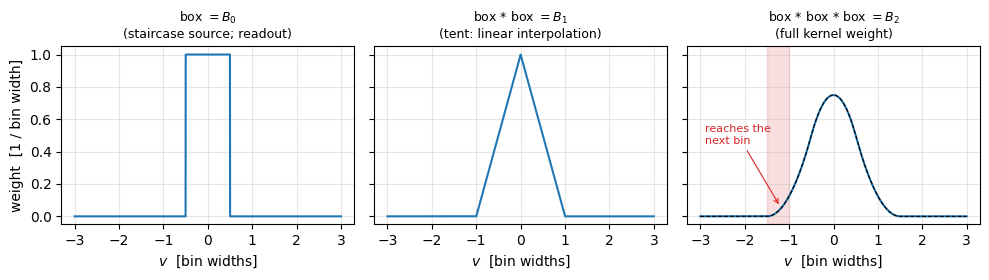

In [3]:
# B2 built literally, by convolving a box with itself twice,
# against the closed form (2.2).
n_sub = 2000  # samples per bin width
v = np.arange(-3 * n_sub, 3 * n_sub + 1) / n_sub
box = np.where(np.abs(v) < 0.5, 1.0, 0.0)
tent = np.convolve(box, box, mode="same") / n_sub
b2_conv = np.convolve(tent, box, mode="same") / n_sub


def b2_closed(v):
    v = np.abs(v)
    return np.where(
        v <= 0.5,
        0.75 - v**2,
        np.where(v <= 1.5, 0.5 * (1.5 - v) ** 2, 0.0),
    )


print(
    "max |B2 by convolution - closed form (2.2)| =",
    np.max(np.abs(b2_conv - b2_closed(v))),
    "(discretisation of the numerical convolution)",
)

fig, axes = plt.subplots(1, 3, figsize=(10, 2.9), sharey=True)
labels = [
    "box $= B_0$\n(staircase source; readout)",
    "box * box $= B_1$\n(tent: linear interpolation)",
    "box * box * box $= B_2$\n(full kernel weight)",
]
for ax, y, label in zip(axes, [box, tent, b2_conv], labels):
    ax.plot(v, y)
    ax.set_xlabel(r"$v$  [bin widths]")
    ax.set_title(label, fontsize=9)
axes[0].set_ylabel("weight  [1 / bin width]")
axes[2].plot(v, b2_closed(v), "k--", lw=0.8)
axes[2].axvspan(-1.5, -1.0, color="C3", alpha=0.15)
axes[2].annotate(
    "reaches the\nnext bin",
    xy=(-1.2, 0.06),
    xytext=(-2.9, 0.45),
    fontsize=8,
    color="C3",
    arrowprops={"arrowstyle": "->", "color": "C3", "lw": 0.8},
)
plt.tight_layout()
plt.show()

## 3. Why three boxes: sampling folds the impedance

The sum (2.1) applies $\overline W$ only at whole-bin lags. A discrete
convolution cannot see what its kernel does *between* the samples: by
Poisson's summation formula, the transfer function it applies is the
**folded** spectrum. With $k$ box averages on the wake,
$\widetilde{W \ast \mathrm{box}^{\ast k}}(f) = Z(f)\operatorname{sinc}^k
(f\Delta t)$, where $\operatorname{sinc}(x) = \sin(\pi x)/(\pi x)$ is the
transform of the unit box (NumPy's convention), and

$$Z_\mathrm{eff}(f)
\;=\; \Delta t \sum_{n} \overline W(n\Delta t)\, e^{-2\pi i f n \Delta t}
\;\overset{\text{Poisson}}{=}\;
\sum_{m=-\infty}^{\infty} Z\!\left(f + \tfrac{m}{\Delta t}\right)
\operatorname{sinc}^{k}\!\left(f\Delta t + m\right) , \tag{3.1}$$

in the sense that the model output obeys
$\widetilde V(f) = Z_\mathrm{eff}(f)\,\tilde q(f)$ with
$\tilde q(f) = \sum_j q_j e^{-2\pi i f t_j}$ (verified to $10^{-13}$ in
section 7). The term $m = 0$ is the physical band; every $m \ne 0$ is an
alias image, suppressed by $\operatorname{sinc}^k$ as $|m|^{-k}$. Below the
Nyquist frequency $\operatorname{sinc}^k$ is real and positive: box averaging
damps amplitudes, it shifts nothing in time.

Sign structure: $\sin(\pi(x+m)) = (-1)^m \sin(\pi x)$ gives

$$\operatorname{sinc}^k(f\Delta t + m) = (-1)^{km}\,
\frac{\sin^k(\pi f\Delta t)}{\bigl(\pi(f\Delta t + m)\bigr)^{k}} ,$$

so the image weights are non-negative for even $k$ — the alias
contribution then only ever *adds* loss for $\operatorname{Re} Z
\ge 0$, though the $m = 0$ band is still damped by
$\operatorname{sinc}^k < 1$, so a fully resolved resonator lands
below one even at $k = 2$ — and they alternate with $m$ for odd
$k$: hence one box ($k = 1$) can even fabricate energy *gain*, and
$k = 3$'s images partially cancel across a broad resonance. The
$|m|^{-3}$ envelope holds regardless of the signs. A caution on
reading the table below: the near-equal $k = 3$ and $k = 4$ totals
do *not* mean the alias residue vanishes — the band/alias split
(checked below the table) gives, at 2.4 bins/$\sigma$ with
weighting (b), $0.968 + 0.010$ for $k = 3$ and $0.958 + 0.020$ for
$k = 4$. The alias residue *opposes* the in-band damping — it adds
loss where the band is damped — cancelling about a third of it at
$k = 3$; and $k = 4$ carries *more* alias despite its faster
envelope, because its images add with one sign while $k = 3$'s partially cancel. The
near-equal totals are a compensation of the two effects.

* $k = 0$ — point-sampling the wake — suppresses nothing: a resonance above
  $1/(2\Delta t)$ folds undiminished onto the bunch's own frequencies. This
  is the classic low-$Q$ / broadband-resonator failure of naive time-domain
  solvers.
* $k = 2$ — staircase source plus observation average — is the *exact*
  voltage of a staircase bunch, but the $|m|^{-2}$ tail still folds the
  images down — all with non-negative weight, so this alias leak can
  only add loss, never gain. What an above-Nyquist resonance folds into the band is its
  **resistive** part, landing at frequencies where the true impedance is
  essentially reactive. A reactive impedance does no net work on the beam,
  so the leak is directly measurable as fabricated energy loss: the **loss
  factor** is the sharp diagnostic.
* $k = 3$ suppresses the tail as $|m|^{-3}$, which restores the loss factor
  at any binning; $k = 4$ changes nothing measurable while damping the
  physical band further.

The in-band price of $k = 3$ is the amplitude factor

$$\operatorname{sinc}^3(f\Delta t)
= 1 - \tfrac12\,(\pi f \Delta t)^2 + \mathcal O\big((f\Delta t)^4\big),$$

second order in the bin width: it vanishes under refinement, while the
aliasing it prevents does not (for a resonance that stays above Nyquist).

The demonstration below uses the parameters from the
`Resonators._wake_bin_average` docstring: a Gaussian bunch,
$\sigma = 12\,\mathrm{ns}$, against a broadband resonator
($f_r = 1\,\mathrm{GHz}$, $Q = 0.907$, $R_s = 1\,\Omega$), binned at 2.4 bins
per $\sigma$ — $\Delta t = 5\,\mathrm{ns}$, Nyquist at $f_r / 10$.

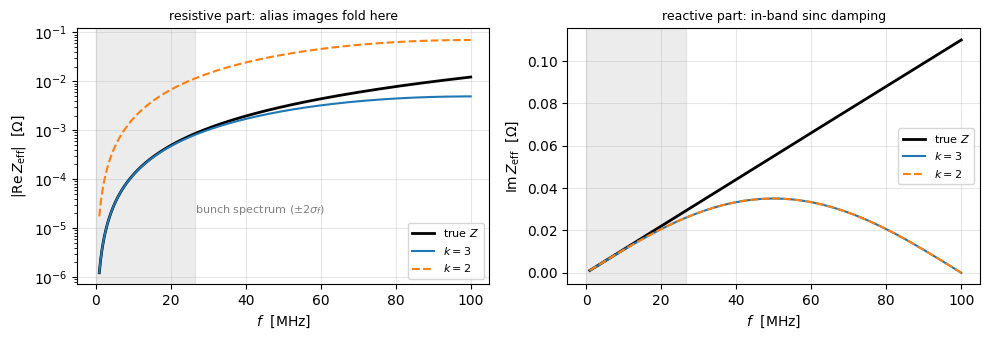

In [4]:
# The folded impedance (3.1) for the broadband resonator.
R_bb, f_r, Q_bb = 1.0, 1.0e9, 0.907
omega_r = 2 * np.pi * f_r
alpha_bb = omega_r / (2 * Q_bb)
omega_bar_bb = np.sqrt(omega_r**2 - alpha_bb**2)
pole_bb = -alpha_bb + 1j * omega_bar_bb
rho_bb = R_bb * alpha_bb * (1 + 1j * alpha_bb / omega_bar_bb)


def impedance(f, pole, rho):
    s = 2j * np.pi * f
    return rho / (s - pole) + np.conj(rho) / (s - np.conj(pole))


def z_effective(f, dt, k, pole, rho, m_max=400):
    total = np.zeros(np.shape(f), dtype=complex)
    for m in range(-m_max, m_max + 1):
        total += impedance(f + m / dt, pole, rho) * np.sinc(f * dt + m) ** k
    return total


sigma = 12e-9
dt_coarse = sigma / 2.4  # 5 ns; Nyquist = 100 MHz = f_r / 10
sigma_f = 1 / (2 * np.pi * sigma)  # bunch spectrum: exp(-(f / sigma_f)^2 / 2)
f_band = np.linspace(1e6, 0.5 / dt_coarse, 600)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
z_true = impedance(f_band, pole_bb, rho_bb)
z2 = z_effective(f_band, dt_coarse, 2, pole_bb, rho_bb)
z3 = z_effective(f_band, dt_coarse, 3, pole_bb, rho_bb)
axes[0].semilogy(
    f_band / 1e6, np.abs(z_true.real), "k", lw=2, label="true $Z$"
)
axes[0].semilogy(f_band / 1e6, np.abs(z3.real), "C0-", label="$k = 3$")
axes[0].semilogy(f_band / 1e6, np.abs(z2.real), "C1--", label="$k = 2$")
axes[0].set_ylabel(r"$|\mathrm{Re}\,Z_\mathrm{eff}|$  [$\Omega$]")
axes[0].set_title("resistive part: alias images fold here", fontsize=9)
axes[1].plot(f_band / 1e6, z_true.imag, "k", lw=2, label="true $Z$")
axes[1].plot(f_band / 1e6, z3.imag, "C0-", label="$k = 3$")
axes[1].plot(f_band / 1e6, z2.imag, "C1--", label="$k = 2$")
axes[1].set_ylabel(r"$\mathrm{Im}\,Z_\mathrm{eff}$  [$\Omega$]")
axes[1].set_title("reactive part: in-band sinc damping", fontsize=9)
for ax in axes:
    ax.axvspan(0, 2 * sigma_f / 1e6, color="grey", alpha=0.15)
    ax.set_xlabel("$f$  [MHz]")
    ax.legend(fontsize=8)
axes[0].annotate(
    r"bunch spectrum ($\pm 2\sigma_f$)",
    xy=(2 * sigma_f / 1e6, 2e-5),
    fontsize=8,
    color="grey",
)
plt.tight_layout()
plt.show()

In [5]:
# Loss factor of the discrete model, normalised to the continuum
# (k_loss ~ integral Re Z |lambda~|^2 df), in two weightings:
# (a) with the data's sinc (lambda~ sinc; the q_j are bin
#     integrals, section 2) -- the energy the model actually
#     transfers from the histogram data;
# (b) without it (lambda~ alone) -- the kernel in isolation; this is
#     the weighting of the table in the Resonators._wake_bin_average
#     docstring.
f_full = np.linspace(0.1e6, 3000e6, 300000)
bunch_power_full = np.exp(-((2 * np.pi * f_full * sigma) ** 2))
k_loss_true = np.trapezoid(
    impedance(f_full, pole_bb, rho_bb).real * bunch_power_full, f_full
)

print("loss factor, discrete model / continuum\n")
for name, with_histogram_sinc in [
    ("(a) weight |lambda~ sinc|^2  (model from histogram data)", True),
    ("(b) weight |lambda~|^2       (kernel isolated; docstring)", False),
]:
    print(name)
    print("bins/sigma" + "".join(f"      k={k}" for k in (1, 2, 3, 4)))
    for bins_per_sigma in (2.4, 7.2, 24.0):
        dt_ = sigma / bins_per_sigma
        f_ = np.linspace(0.01e6, 0.5 / dt_, 4000)
        weight = np.exp(-0.5 * (2 * np.pi * f_ * sigma) ** 2)
        if with_histogram_sinc:
            weight = weight * np.sinc(f_ * dt_)
        weight = weight**2
        ratios = []
        for k in (1, 2, 3, 4):
            re_zeff = z_effective(f_, dt_, k, pole_bb, rho_bb).real
            ratios.append(np.trapezoid(re_zeff * weight, f_) / k_loss_true)
        print(
            f"{bins_per_sigma:10.1f}" + "".join(f" {r:+8.3f}" for r in ratios)
        )
    print()

# Check (band/alias split, weighting (b)): the near-equal k = 3 and
# k = 4 totals are a compensation -- k = 4 damps the band more AND
# carries more alias (all images one sign); k = 3's images partially
# cancel.
print("split, weighting (b):  band (m=0) + alias (m!=0) = total")
for bins_per_sigma in (2.4, 7.2):
    dt_ = sigma / bins_per_sigma
    f_ = np.linspace(0.01e6, 0.5 / dt_, 4000)
    weight = np.exp(-((2 * np.pi * f_ * sigma) ** 2))
    for k in (2, 3, 4):
        band = (
            np.trapezoid(
                (impedance(f_, pole_bb, rho_bb) * np.sinc(f_ * dt_) ** k).real
                * weight,
                f_,
            )
            / k_loss_true
        )
        total = (
            np.trapezoid(
                z_effective(f_, dt_, k, pole_bb, rho_bb).real * weight, f_
            )
            / k_loss_true
        )
        print(
            f"  {bins_per_sigma:4.1f} bins/sigma, k={k}:"
            f"  {band:+7.3f}  {total - band:+8.3f}  = {total:+7.3f}"
        )

loss factor, discrete model / continuum

(a) weight |lambda~ sinc|^2  (model from histogram data)
bins/sigma      k=1      k=2      k=3      k=4


       2.4   +0.046  +13.646   +0.958   +0.957


       7.2   -3.099   +4.715   +0.995   +0.995


      24.0   +1.435   +1.155   +1.000   +0.999

(b) weight |lambda~|^2       (kernel isolated; docstring)
bins/sigma      k=1      k=2      k=3      k=4


       2.4   +0.047  +13.939   +0.978   +0.978


       7.2   -3.106   +4.726   +0.997   +0.997


      24.0   +1.435   +1.155   +1.000   +1.000

split, weighting (b):  band (m=0) + alias (m!=0) = total
   2.4 bins/sigma, k=2:   +0.979   +12.961  = +13.939


   2.4 bins/sigma, k=3:   +0.968    +0.010  =  +0.978
   2.4 bins/sigma, k=4:   +0.958    +0.020  =  +0.978


   7.2 bins/sigma, k=2:   +0.998    +3.729  =  +4.726
   7.2 bins/sigma, k=3:   +0.996    +0.001  =  +0.997


   7.2 bins/sigma, k=4:   +0.995    +0.002  =  +0.997


Reading the table: one box is erratic — at 7.2 bins per $\sigma$ the
fabricated loss even has the wrong sign (spurious energy *gain*); two boxes
inflate the loss factor up to fourteen-fold at coarse binning; three boxes
hold it within a few per cent even at 2.4 bins per $\sigma$ and are exact by
24; a fourth box would change nothing. Three is the right stopping point, and
$B_2$ in (2.1) is that choice.

Table (b) — weighted with $|\tilde\lambda|^2$ alone, without the
data's sinc — reproduces exactly the numbers quoted in the
`Resonators._wake_bin_average` docstring (0.978, 13.9, …): it
isolates the kernel. Table (a) additionally weights with the data's
histogram $\operatorname{sinc}$ and measures the energy the model
actually transfers from the histogram. The conclusion is the same
either way.

## 4. Closed form of the bin-averaged kernel

The recursion needs $\overline W$ in closed form. One box average is a
difference of an antiderivative,

$$(g \ast \mathrm{box})(\tau)
= \frac{1}{\Delta t}\int_{\tau - \Delta t/2}^{\tau + \Delta t/2} g
= \frac{G\!\left(\tau + \tfrac{\Delta t}{2}\right)
      - G\!\left(\tau - \tfrac{\Delta t}{2}\right)}{\Delta t},
\qquad G' = g ,$$

so three box averages are the **third symmetric difference of a third
antiderivative** $A_3$ (any function with $A_3''' = W$):

$$\overline W(\tau) = \frac{
      A_3\!\left(\tau + \tfrac32\Delta t\right)
- 3\, A_3\!\left(\tau + \tfrac12\Delta t\right)
+ 3\, A_3\!\left(\tau - \tfrac12\Delta t\right)
-     A_3\!\left(\tau - \tfrac32\Delta t\right)}{\Delta t^3} . \tag{4.1}$$

The third difference annihilates any globally added polynomial of
degree two or less, so integration constants are never the
obstacle. What matters is that $A_3$ be a genuine third
antiderivative on the **whole axis** — in particular $C^2$ across
the jump at $\tau = 0$, where $W$ switches on; gluing per-side
antiderivatives with mismatched polynomial parts does not qualify.
Per pole, the unique third antiderivative of
$e^{p\tau}\,\Theta(\tau)$ that joins $C^2$-smoothly to zero is

$$\varphi_3(\tau) = \begin{cases}
\dfrac{e^{p\tau} - 1 - p\tau - \tfrac12 (p\tau)^2}{p^{3}}, & \tau > 0,\\[6pt]
0, & \tau \le 0,
\end{cases}
\qquad A_3(\tau) = 2\operatorname{Re}\!\left[\rho\,\varphi_3(\tau)\right] :
\tag{4.2}$$

the subtracted quadratic is exactly what makes
$\varphi_3(0) = \varphi_3'(0) = \varphi_3''(0) = 0$, while
$\varphi_3''' = e^{p\tau}$ for $\tau > 0$.

**The far zone.** For $\tau > \tfrac32\Delta t$ all four arguments in (4.1)
are positive. The polynomial part of $\varphi_3$ is a quadratic in $\tau$,
and a third difference annihilates quadratics identically — only the
exponential survives:

$$\overline W(\tau)\Big|_{\tau > \frac32\Delta t}
= 2\operatorname{Re}\!\left[\rho
\left(\frac{e^{p\Delta t} - 1}{p\Delta t}\right)^{\!3}
e^{\,p\left(\tau - \frac32\Delta t\right)}\right] . \tag{4.3}$$

This is forced, not fortunate: once the whole averaging window
$\left(\tau - \tfrac32\Delta t,\ \tau + \tfrac32\Delta t\right)$ lies in the
causal region it sees a pure exponential, and convolving an exponential with
*any* fixed window returns that same exponential times a constant. The
averaging produces a genuinely different function only where the window
**straddles the onset**, $|\tau| < \tfrac32\Delta t$ — the near field. For
$\tau \le -\tfrac32\Delta t$ the window sees nothing: $\overline W \equiv 0$.

**Two evaluation forms, deliberately.** (4.1) and (4.3) are the same
function wherever both apply, but not in floating point. In (4.1) the
polynomial parts grow like $(p\tau)^2$ before cancelling, so its rounding
error grows quadratically with the lag; (4.3) never cancels and, for a
damped pole, keeps every factor bounded by one
($\left|\frac{e^{z} - 1}{z}\right| = \left|\int_0^1 e^{z u}\,\mathrm{d}u
\right| \le 1$ for $\operatorname{Re} z \le 0$). BLonD therefore evaluates
(4.1) only across the onset and (4.3) beyond it
(`triple_box_average_pole`); and for $|p\tau| < 1$, where the numerator of
(4.2) itself cancels to $\mathcal O\!\left((p\tau)^3\right)$, it sums the
series $\varphi_3 = \tau^3 \sum_k (p\tau)^k / (k+3)!$ instead. Both effects
are measured two cells below.

In [6]:
# Symbolic checks of section 4, in units dt = 1.
p_s = sp.symbols("p", nonzero=True)  # pole, in 1/bin
x = sp.symbols("x", positive=True)
tau_s, v_s = sp.symbols("tau v", real=True)

phi3_s = (sp.exp(p_s * x) - 1 - p_s * x - (p_s * x) ** 2 / 2) / p_s**3
print(
    "phi3''' - e^(p x):", sp.simplify(sp.diff(phi3_s, x, 3) - sp.exp(p_s * x))
)
print(
    "phi3, phi3', phi3'' at 0+:",
    sp.limit(phi3_s, x, 0),
    sp.limit(sp.diff(phi3_s, x), x, 0),
    sp.limit(sp.diff(phi3_s, x, 2), x, 0),
)

# B2 piece by piece (support (-3/2, 3/2)):
b2_pieces = [
    (
        (sp.Rational(3, 2) + v_s) ** 2 / 2,
        sp.Rational(-3, 2),
        sp.Rational(-1, 2),
    ),
    (sp.Rational(3, 4) - v_s**2, sp.Rational(-1, 2), sp.Rational(1, 2)),
    ((sp.Rational(3, 2) - v_s) ** 2 / 2, sp.Rational(1, 2), sp.Rational(3, 2)),
]


def phi3_causal(arg):
    return phi3_s.subs(x, arg) if arg > 0 else sp.Integer(0)


def third_difference(t):
    t = sp.Rational(t)
    return (
        phi3_causal(t + sp.Rational(3, 2))
        - 3 * phi3_causal(t + sp.Rational(1, 2))
        + 3 * phi3_causal(t - sp.Rational(1, 2))
        - phi3_causal(t - sp.Rational(3, 2))
    )


def window_integral(t):
    # integral of B2(v) e^{p (t - v)} over the causal part of the window
    t = sp.Rational(t)
    total = sp.Integer(0)
    for poly, lo, hi in b2_pieces:
        hi = sp.Min(hi, t)
        if hi <= lo:
            continue
        total += sp.integrate(
            poly * sp.exp(p_s * (t - v_s)), (v_s, lo, hi), conds="none"
        )
    return total


for t in (-1, 0, 1):
    print(
        f"window integral - (4.1) at tau = {t:+d}:",
        sp.simplify(sp.expand(window_integral(t) - third_difference(t))),
    )

# far zone: the full window against (4.3), at generic tau ...
far_claim = ((sp.exp(p_s) - 1) / p_s) ** 3 * sp.exp(
    p_s * (tau_s - sp.Rational(3, 2))
)
full_window = sum(
    sp.integrate(
        poly * sp.exp(p_s * (tau_s - v_s)), (v_s, lo, hi), conds="none"
    )
    for poly, lo, hi in b2_pieces
)
print(
    "full window integral - (4.3):",
    sp.simplify(sp.expand(full_window - far_claim)),
)

# ... and the polynomial cancellation: the third difference of the
# *analytic* phi3 (no causal cutoff) equals (4.3) identically.
analytic_third_difference = (
    phi3_s.subs(x, tau_s + sp.Rational(3, 2))
    - 3 * phi3_s.subs(x, tau_s + sp.Rational(1, 2))
    + 3 * phi3_s.subs(x, tau_s - sp.Rational(1, 2))
    - phi3_s.subs(x, tau_s - sp.Rational(3, 2))
)
print(
    "third difference of analytic phi3 - (4.3):",
    sp.simplify(sp.expand(analytic_third_difference - far_claim)),
)

phi3''' - e^(p x): 0
phi3, phi3', phi3'' at 0+: 0 0 0


window integral - (4.1) at tau = -1: 0
window integral - (4.1) at tau = +0: 0


window integral - (4.1) at tau = +1: 0
full window integral - (4.3): 0
third difference of analytic phi3 - (4.3): 0


In [7]:
# Numerical checks of (4.1)/(4.3): against brute-force integration
# of B2(v) W(tau - v dt), and against BLonD's own implementation.
def phi3(tau, pole):
    tau = np.asarray(tau, dtype=float)
    out = np.zeros(tau.shape, dtype=complex)
    causal = tau > 0
    z = pole * tau[causal]
    out[causal] = (np.exp(z) - 1 - z - z**2 / 2) / pole**3
    return out


def wbar_via_phi3(tau, pole, rho, dt):
    # (4.1): valid everywhere, loses digits at large |p tau|
    third_diff = (
        phi3(tau + 1.5 * dt, pole)
        - 3 * phi3(tau + 0.5 * dt, pole)
        + 3 * phi3(tau - 0.5 * dt, pole)
        - phi3(tau - 1.5 * dt, pole)
    )
    return 2 * np.real(rho * third_diff) / dt**3


def wbar_far(tau, pole, rho, dt):
    # (4.3): valid for tau > 1.5 dt, every factor bounded by one
    z = pole * dt
    return 2 * np.real(
        rho
        * (np.expm1(z) / z) ** 3
        * np.exp(pole * (np.asarray(tau, dtype=float) - 1.5 * dt))
    )


def wbar(tau, pole, rho, dt):
    # hybrid, exactly as blond's triple_box_average_pole: (4.1) across
    # the onset, (4.3) beyond it; each branch's argument clamped to its
    # own side so the discarded values stay finite
    tau = np.asarray(tau, dtype=float)
    onset = 1.5 * dt
    far = tau > onset
    tau_far = np.where(far, tau, onset)
    tau_near = np.where(far, onset, tau)
    return np.where(
        far,
        wbar_far(tau_far, pole, rho, dt),
        wbar_via_phi3(tau_near, pole, rho, dt),
    )


# demo resonator, deliberately under-resolved: the oscillation period
# 1 / 0.7 GHz = 1.43 ns is barely more than the bin width
R_demo, f_r_demo, Q_demo = 1.0, 0.7e9, 11.0
dt_demo = 1.0e-9
omega_demo = 2 * np.pi * f_r_demo
alpha_demo = omega_demo / (2 * Q_demo)
omega_bar_demo = np.sqrt(omega_demo**2 - alpha_demo**2)
pole_demo = -alpha_demo + 1j * omega_bar_demo
rho_demo = R_demo * alpha_demo * (1 + 1j * alpha_demo / omega_bar_demo)


def b2_scalar(v):
    av = abs(v)
    if av <= 0.5:
        return 0.75 - v * v
    if av <= 1.5:
        return 0.5 * (1.5 - av) ** 2
    return 0.0


def wbar_bruteforce(tau, pole, rho, dt):
    def integrand(v):
        arg = tau - v * dt
        if arg <= 0:
            return 0.0
        return b2_scalar(v) * 2 * np.real(rho * np.exp(pole * arg))

    onset_crossing = min(max(tau / dt, -1.5), 1.5)
    pts = sorted({-1.5, -0.5, 0.5, 1.5, onset_crossing})
    return quad(integrand, -1.5, 1.5, points=pts, limit=200)[0]


import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    from blond.physics.impedances.bin_average import (
        triple_box_average_pole,
    )

print("lag [bins]   brute force      (4.1)/(4.3)     blond")
lags = np.array([-2.0, -1.4, -1.0, -0.5, 0.0, 0.5, 1.0, 1.4, 2.0, 3.0, 5.5])
worst = 0.0
for m in lags:
    t_ = m * dt_demo
    brute = wbar_bruteforce(t_, pole_demo, rho_demo, dt_demo)
    mine = float(wbar(np.array([t_]), pole_demo, rho_demo, dt_demo)[0])
    ref = float(
        triple_box_average_pole(np.array([t_]), pole_demo, rho_demo, dt_demo)[
            0
        ]
    )
    worst = max(worst, abs(brute - mine), abs(ref - mine))
    print(f"{m:+9.1f}   {brute:+.6e}   {mine:+.6e}   {ref:+.6e}")
print(
    "worst absolute disagreement:",
    worst,
    f"(kernel scale {2 * abs(rho_demo):.2e})",
)

# the (4.1)-only route's rounding error grows ~ lag^2; the hybrid stays
# at rounding level
print("\n(4.1)-route error vs hybrid, growing lag:")
for m in (2, 8, 32, 128, 512):
    a = float(
        wbar_via_phi3(np.array([m * dt_demo]), pole_demo, rho_demo, dt_demo)[0]
    )
    b = float(wbar(np.array([m * dt_demo]), pole_demo, rho_demo, dt_demo)[0])
    print(f"  lag {m:4d} bins:  |difference| = {abs(a - b):.2e}")

lag [bins]   brute force      (4.1)/(4.3)     blond
     -2.0   +0.000000e+00   +0.000000e+00   +0.000000e+00
     -1.4   +6.534588e+04   +6.534588e+04   +6.534588e+04
     -1.0   +6.245701e+06   +6.245701e+06   +6.245701e+06
     -0.5   +2.377546e+07   +2.377546e+07   +2.377546e+07
     +0.0   +1.109149e+07   +1.109149e+07   +1.109149e+07
     +0.5   -3.251405e+07   -3.251405e+07   -3.251405e+07
     +1.0   -1.666324e+07   -1.666324e+07   -1.666324e+07
     +1.4   +1.395241e+07   +1.395241e+07   +1.395241e+07
     +2.0   -8.055328e+06   -8.055328e+06   -8.055328e+06
     +3.0   +1.071705e+07   +1.071705e+07   +1.071705e+07
     +5.5   +1.994246e+06   +1.994246e+06   +1.994246e+06
worst absolute disagreement: 6.05359673500061e-08 (kernel scale 4.00e+08)

(4.1)-route error vs hybrid, growing lag:
  lag    2 bins:  |difference| = 1.58e-08
  lag    8 bins:  |difference| = 9.41e-08
  lag   32 bins:  |difference| = 8.98e-07
  lag  128 bins:  |difference| = 1.45e-05
  lag  512 bins:  |differ

## 5. The far field: a one-state recursion, lagging by two bins

Split the sum (2.1) by lag — from two bins on, the far form (4.3)
holds; the three nearest lags are section 6's business:

$$V_i \;=\;
\underbrace{\sum_{j \le i-2} q_j\, \overline W\big((i-j)\Delta t\big)}
_{\text{far field: geometric}}
\;+\;
\underbrace{q_{i-1}\,\overline W(\Delta t) + q_i\,\overline W(0)
          + q_{i+1}\,\overline W(-\Delta t)}
_{\text{near field: three taps}} . \tag{5.1}$$

**What is to be solved.** The far-field term is a sum over the entire
history: evaluated directly, $\mathcal O(N)$ multiplications per bin
and $\mathcal O(N^2)$ per turn. Wanted: an update rule that produces
the *same numbers* at $\mathcal O(1)$ per bin. Three steps.

**Insert the closed form.** Every term of the far sum has lag
$m = i - j \ge 2$, i.e. $\tau = m\Delta t > \tfrac32\Delta t$ — (4.3)
applies exactly. Writing
$\tau - \tfrac32\Delta t = (m-2)\,\Delta t + \tfrac12\Delta t$ (whole
bins beyond the lag $2\Delta t$, plus the leftover half bin down to
the reference point of (4.3)),

$$\overline W(m\Delta t)
= 2\operatorname{Re}\!\Bigg[
\underbrace{\rho\left(\frac{e^{p\Delta t}-1}{p\Delta t}\right)^{\!3}
e^{\,p\Delta t/2}}_{=:\ \rho_\mathrm{rec}}\;
\underbrace{\big(e^{p\Delta t}\big)^{m-2}}_{=:\ z^{\,m-2}}
\Bigg] .$$

A geometric sequence in the lag: one bin further, one more factor
$z$.

**Pull the sum inside.** The $q_j$ are real and $\operatorname{Re}$ is
linear, so

$$V_i^{\mathrm{far}}
= \sum_{j \le i-2} q_j\, 2\operatorname{Re}\!\big[\rho_\mathrm{rec}\,
z^{\,i-2-j}\big]
= 2\operatorname{Re}\!\Bigg[\rho_\mathrm{rec}
\underbrace{\sum_{j \le i-2} q_j\, z^{\,i-2-j}}_{=:\ S_i}\Bigg] .$$

All the $i$-dependence now sits in one complex number. Physically,
$z^{\,i-2-j} = e^{\,p(T_i - t_j)}$ with $T_i = t_i - 2\Delta t$: $S_i$
is the phasor sum of every due charge, decayed and rotated from its
emission time $t_j$ to the **emission clock** $T_i$ — hence the name.

**Split off the newest term.** $S_i$ solves a linear first-order
difference equation: take out $j = i-2$ (exponent zero) and factor one
$z$ from the rest,

$$S_i
= q_{i-2} + \sum_{j \le i-3} q_j\, z^{\,i-2-j}
= q_{i-2} + z \sum_{j \le i-3} q_j\, z^{\,(i-1)-2-j}
= z\, S_{i-1} + q_{i-2} ,$$

with $S_i = 0$ until the first charge comes due. Solving this
recurrence forward — decay by $z$, inject $q_{i-2}$, read out
$V_i^{\mathrm{far}} = 2\operatorname{Re}[\rho_\mathrm{rec}\, S_i]$ —
reproduces the convolution sum term by term: nothing is approximated;
the recurrence *is* the sum, regrouped. ($S$ is at the same time the
exact solution of the driven oscillator equation
$\dot S = p\,S + \sum_j q_j\,\delta(t - t_j)$, sampled at the clocks
$T_i$ — the same bookkeeping as a cavity's beam-loading phasor.)
Cost: one multiply-add per bin and pole instead of $\mathcal O(N)$.
This is `wake_from_pole_residue` with `STATE_LAG_BINS = 2`; the
shipped kernel folds the conjugate-pair factor 2 into the injected
charge instead of the readout — same product — and injects a real
pole undoubled.

**Why let the state lag, rather than reference it at $t_i$?**
Referencing at $t_i$ leaves the recursion itself benign — decay $z$,
injection $z^2 q$, both of magnitude $\le 1$ — and for moderate
damping the factor $e^{-2p\Delta t}$ in the readout residue is a
harmless rescaling (broadband resonator of section 3, $\Delta t = 5$
ns: $e^{2\alpha\Delta t} \approx 10^{15}$, with no cancellation
involved). But the solver promises *any* damped pole at *any*
binning, and there the $t_i$-referenced form has a hard boundary: its
readout constant grows like $e^{3\alpha\Delta t/2}/(\alpha\Delta t)^3$
and overflows at $\alpha\Delta t$ of a few hundred — where exactly
depends on the evaluation order: as a separate factor
$e^{2\alpha\Delta t}$ already at $\alpha\Delta t \approx 355$, folded
into one exponent only at $\alpha\Delta t \approx 480$. Beyond that,
$\infty \cdot 0 = \mathrm{NaN}$ (the state has long underflowed to
zero); below it, the folded form silently returns $0$ for the true —
admittedly tiny — far-field contribution (both evaluations
demonstrated at $\alpha\Delta t = 400$ in the cell after the kernel
figure). With the lag, *every* factor — transition, injection
and readout residue — is bounded by one for any damped pole at any
binning: $|z| = e^{-\alpha\Delta t} \le 1$,
$\left|\frac{e^{p\Delta t}-1}{p\Delta t}\right| \le 1$,
$\left|e^{p\Delta t/2}\right| \le 1$.

The shipped kernel generalises one step further: the decay per event is
$e^{p\,(\mathrm{step} \cdot \Delta t)}$ with a whole-bin step size per event,
so the gaps of a sparse profile and the boundary between turns reuse the same
state — the lag is a *time*, not an array index.

In [8]:
# Check of the three steps: the recurrence reproduces the explicit
# sum S_i = sum_{j <= i-2} q_j z^(i-2-j) term by term.
rng = np.random.default_rng(3)
q_check = rng.random(40)
z_step = np.exp(pole_demo * dt_demo)
state = 0j
worst = 0.0
for i in range(40):
    if i > 0:
        state *= z_step  # decay
    if i >= 2:
        state += q_check[i - 2]  # inject
    explicit = sum(
        q_check[j] * z_step ** (i - 2 - j) for j in range(max(0, i - 1))
    )
    worst = max(worst, abs(state - explicit))
print("check: max |recurrence - explicit sum| =", worst)

check: max |recurrence - explicit sum| = 3.1401849173675503e-16


## 6. The near field: what no one-state recursion can produce

From $m = 2$ onward the recursion's impulse response is $c\, z^m$ — a pure
geometric sequence, for *any* choice of the constant: that is the entire
family a single-state linear recursion can generate — a direct
feed-through term (what a first-order-hold discretisation produces)
adds at most *one* free tap, one degree of freedom where three are
needed. The exact kernel
departs from this family at exactly three grid lags, $m \in \{-1, 0, 1\}$,
where the averaging window straddles the causal onset (section 4). No
re-weighting of the injected charge, no re-tuning of
$\rho_\mathrm{rec}$ and no single feed-through tap can reproduce
all of them: they are three values off the
exponential curve. They therefore enter as the explicit three-tap correction
in (5.1), evaluated from (4.1):

* $q_{i-1}\, \overline W(\Delta t)$ — the previous bin,
* $q_{i}\, \overline W(0)$ — the bin's own charge,
* $q_{i+1}\, \overline W(-\Delta t)$ — the non-causal tap of section 2.

In `MultiPoleSparseSolve` these are `_lag_prev_factors`, `_lag_zero_factor`
and `_lag_next_factors`, tabulated once at setup
(`_setup_near_field_kernel`) and applied as three shifted multiply-adds per
turn (`_add_near_field_voltage`). The figure below shows the whole story in
one frame: one function, two regimes.

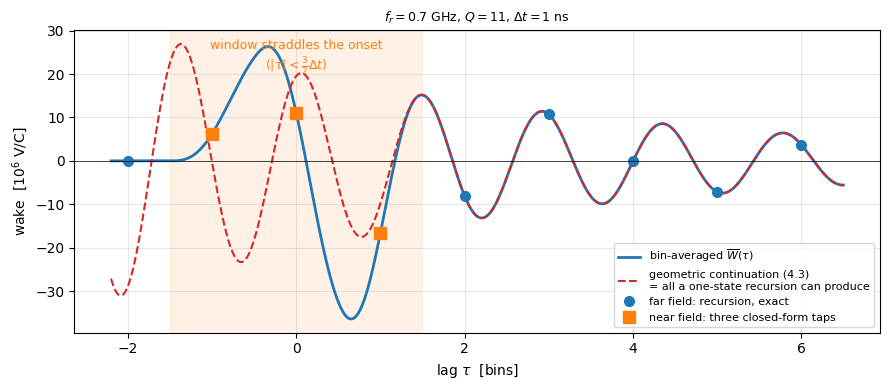

lag m   exact kernel     geometric (4.3)   on the curve?
  -2   +0.000000e+00   -2.890218e+07   False
  -1   +6.245701e+06   -3.007820e+05   False
  +0   +1.109149e+07   +1.953116e+07   False
  +1   -1.666324e+07   -9.820159e+06   False
  +2   -8.055328e+06   -8.055328e+06   True
  +3   +1.071705e+07   +1.071705e+07   True
  +4   -9.860538e+04   -9.860538e+04   True
  +5   -7.134414e+06   -7.134414e+06   True
  +6   +3.726911e+06   +3.726911e+06   True


In [9]:
# The bin-averaged kernel, its geometric continuation, and the
# three taps the recursion cannot represent. (The raw wake is ~12x
# larger here -- an under-resolved pole is averaged down strongly --
# and is left out of the frame.)
tau_fine = np.linspace(-2.2, 6.5, 3000) * dt_demo
kernel_fine = wbar(tau_fine, pole_demo, rho_demo, dt_demo)
geometric_fine = wbar_far(tau_fine, pole_demo, rho_demo, dt_demo)

m_grid = np.arange(-2, 7)
kernel_taps = wbar(m_grid * dt_demo, pole_demo, rho_demo, dt_demo)
near = (m_grid >= -1) & (m_grid <= 1)

scale = 1e6
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    tau_fine / dt_demo,
    kernel_fine / scale,
    "C0",
    lw=2,
    label=r"bin-averaged $\overline{W}(\tau)$",
)
ax.plot(
    tau_fine / dt_demo,
    geometric_fine / scale,
    "C3--",
    lw=1.5,
    label="geometric continuation (4.3)\n"
    "= all a one-state recursion can produce",
)
ax.plot(
    m_grid[~near],
    kernel_taps[~near] / scale,
    "C0o",
    ms=7,
    label="far field: recursion, exact",
)
ax.plot(
    m_grid[near],
    kernel_taps[near] / scale,
    "C1s",
    ms=8,
    label="near field: three closed-form taps",
)
ax.axvspan(-1.5, 1.5, color="C1", alpha=0.10)
ax.text(
    0,
    0.97,
    "window straddles the onset\n"
    r"($|\tau| < \frac{3}{2}\Delta t$)",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=9,
    color="C1",
)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel(r"lag $\tau$  [bins]")
ax.set_ylabel(r"wake  [$10^{6}$ V/C]")
ax.set_title(
    rf"$f_r = {f_r_demo / 1e9:.1f}$ GHz, $Q = {Q_demo:.0f}$,"
    rf" $\Delta t = {dt_demo * 1e9:.0f}$ ns",
    fontsize=9,
)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print("lag m   exact kernel     geometric (4.3)   on the curve?")
for m, k_val in zip(m_grid, kernel_taps):
    geo = float(
        wbar_far(np.array([m * dt_demo]), pole_demo, rho_demo, dt_demo)[0]
    )
    same = abs(k_val - geo) < 1e-9 * 2 * abs(rho_demo)
    print(f"{m:+4d}   {k_val:+.6e}   {geo:+.6e}   {same}")

In [10]:
# The assembled model against the direct convolution with the
# exact kernel: the split is an identity, not an approximation.
def near_far_voltage(q, pole, rho, dt):
    # reference implementation of MultiPoleSparseSolve's per-pole math
    n = len(q)
    z_dt = pole * dt
    decay = np.exp(z_dt)
    rho_rec = rho * (np.expm1(z_dt) / z_dt) ** 3 * np.exp(z_dt / 2)
    w_prev, w_self, w_next = wbar(np.array([dt, 0.0, -dt]), pole, rho, dt)
    state = 0j
    voltage = np.zeros(n)
    for i in range(n):
        if i > 0:
            state *= decay  # decay one bin
        if i >= 2:
            state += q[i - 2]  # newly due at the emission clock
        voltage[i] = 2 * np.real(rho_rec * state)  # far field
        voltage[i] += q[i] * w_self  # near field: 3 taps
        if i >= 1:
            voltage[i] += q[i - 1] * w_prev
        if i + 1 < n:
            voltage[i] += q[i + 1] * w_next
    return voltage


rng = np.random.default_rng(7)
q_random = rng.random(64)
lag_axis = np.arange(-63, 64)
kernel_all = wbar(lag_axis * dt_demo, pole_demo, rho_demo, dt_demo)
v_direct = np.array(
    [
        sum(q_random[j] * kernel_all[(i - j) + 63] for j in range(64))
        for i in range(64)
    ]
)
v_split = near_far_voltage(q_random, pole_demo, rho_demo, dt_demo)
print(
    "max |split - direct| / max |V| =",
    np.max(np.abs(v_split - v_direct)) / np.max(np.abs(v_direct)),
)

# Demonstration of section 5's lag argument: extreme damping,
# alpha*dt = 400 -- e.g. a strongly damped real vector-fit pole on a
# coarse grid. With the lag every factor stays representable;
# referenced at t_i, the readout constant (evaluated as the
# separate factor exp(-2 p dt)) overflows while the state
# underflows to zero: the readout is NaN. Folded into one
# exponent it stays finite here (NaN only from alpha*dt ~ 480).
pole_extreme = -400.0 / dt_demo  # real pole, residue 1
z_dt_x = pole_extreme * dt_demo
with np.errstate(over="ignore", under="ignore", invalid="ignore"):
    rho_rec_x = (np.expm1(z_dt_x) / z_dt_x) ** 3 * np.exp(z_dt_x / 2)
    print(
        "with lag:    |z| =",
        abs(np.exp(z_dt_x)),
        "  |rho_rec| =",
        abs(rho_rec_x),
    )
    readout_constant = rho_rec_x * np.exp(-2 * z_dt_x)
    state_no_lag = np.exp(2 * z_dt_x) * 1.0  # injection z^2 q, q = 1
    print(
        "without lag: |readout constant| =",
        abs(readout_constant),
        "  readout =",
        readout_constant * state_no_lag,
    )
    # folded into ONE exponent: still finite at alpha*dt = 400, the
    # readout is silently 0 instead of ~1e-95 (harmless)
    folded_constant = (np.expm1(z_dt_x) / z_dt_x) ** 3 * np.exp(-1.5 * z_dt_x)
    print(
        "without lag, one exponent: |constant| =",
        abs(folded_constant),
        "  readout =",
        folded_constant * state_no_lag,
    )

max |split - direct| / max |V| = 1.2941110009886479e-15
with lag:    |z| = 1.9151695967140057e-174   |rho_rec| = 2.162338323026153e-95
without lag: |readout constant| = inf   readout = nan
without lag, one exponent: |constant| = 5.895344220203032e+252   readout = 0.0


## 7. Residual error

The split itself is exact — the cell above reproduces the direct convolution
with $\overline W$ to machine precision. All modelling error therefore sits
in one place, the substitution $W \to \overline W = W \ast B_2$ applied to
histogrammed data, and it can be read off in either domain.

**Frequency domain.** Relative to the ideal $\widetilde V = Z\,\tilde\lambda$,
the model's in-band transfer is

$$\widetilde V_\mathrm{model}(f) \;\approx\;
Z(f)\, \tilde\lambda(f)\, \operatorname{sinc}^{4}(f\Delta t)
\;+\; \text{alias images of } \mathcal O\!\left(|m|^{-3}\right) ,$$

three sinc factors bought deliberately with $B_2$; the fourth is
not a box of the model but the data property of section 2 — the
$q_j$ are bin *integrals*, so $\tilde q$ carries
$\tilde\lambda\,\operatorname{sinc}$ in band. That factor is
common to every solver that consumes the histogram, and if the
readout is compared against the bin-*averaged* ideal voltage
rather than its point values, one sinc sits on both sides and the
model's own deficit is $\operatorname{sinc}^3$. Hence:

* **In-band amplitude damping**,
  $1 - \operatorname{sinc}^4(f\Delta t) \approx \tfrac{2}{3} (\pi f\Delta t)^2$:
  second order in the bin width, a pure real attenuation of the upper end of
  the bunch spectrum — no phase error, no timing shift.
* **Alias remnant**: the $m \ne 0$ images survive at
  $\mathcal O\!\left(|m|^{-3}\right)$; for an above-Nyquist resonance this is
  the residual fabricated resistance. The band/alias split of section 3
  puts it at $+0.010$ of the continuum loss factor at 2.4 bins/$\sigma$
  ($+0.001$ at 7.2) — against $14\times$ total for $k = 2$ and sign
  errors for $k = 1$.

**Time domain.** The same statement reads: the line density is treated as
piecewise linear through the bin centres, an
$\mathcal O\!\left(\Delta t^2 \lambda''\right)$ reconstruction error —
confirmed by the measured convergence slope of 2 below.

**Boundary effects.** The non-causal tap needs $q_{i+1}$. At the last bin of
a profile the partner bin lies outside the current call: its tap is dropped
there, and the mirror contribution across a turn boundary is handed over at
the true (generally fractional) lag by the solver's carry logic
(`_carry_previous_call`, `_trailing_tap`) — a one-bin edge effect, absent
for a profile padded with empty bins.

**Floating point.** Two forms of one function are used on purpose — (4.1)
across the onset, (4.3) beyond it; section 4's measurement shows the
(4.1)-only route's error growing $\propto m^2$ while the hybrid stays at
rounding level. The recursion itself is uniformly stable: every factor is
bounded by one for damped poles.

**A caution on reference computations.** The smooth integral is itself
delicate to evaluate naively. A Riemann sum
$\sum_m W(\tau_m)\,\lambda(t - \tau_m)\,\delta\tau$ mishandles the causal
jump at $\tau = 0$ unless the onset sample carries *half* the jump — the
trapezoid rule at a discontinuity, and the same statement as the
beam-loading theorem of section 1. Because the in-band impedance is nearly
reactive, the convolution cancels strongly, and that half-sample convention
alone shifts the result of the example below by a factor of two. The
reference is therefore evaluated spectrally, $\widetilde V = Z\tilde\lambda$
with the analytic Gaussian spectrum, where no such convention exists. The
same trap is why `ImpedanceTableTime` must be *told* how its first tabulated
sample is meant (`first_sample_is_half_jump`).

The two cells below measure the total residual. First the broadband
resonator of section 3 at 7.2 bins per $\sigma$, against the spectral
evaluation of the smooth integral — and, on top, the *predicted* output
$\widetilde V = Z_\mathrm{eff}\,\tilde q$ from (3.1): the model lands on the
prediction to $10^{-13}$, i.e. the residual is a **known, deterministic
filter**, not noise. Then the convergence order on a resolved resonator.

model vs prediction (3.1): 4.1920768214020104e-13
model vs smooth truth:    0.009025958712648326


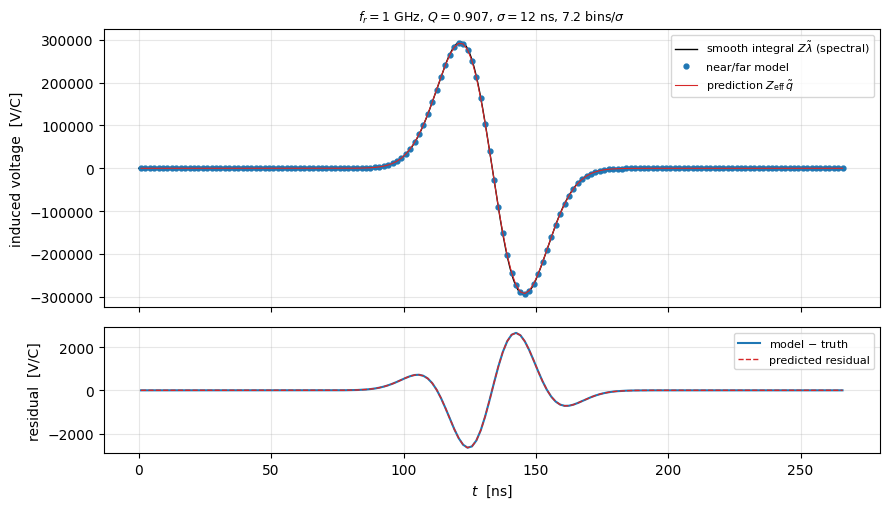

In [11]:
# End to end: smooth truth vs the near/far model, broadband
# resonator (section 3), 7.2 bins per sigma.
bins_per_sigma = 7.2
dt_e = sigma / bins_per_sigma
n_bins = 160
centre = n_bins * dt_e / 2
bin_centres = (np.arange(n_bins) + 0.5) * dt_e

# bin charges of a unit-charge Gaussian, exact via the error function
edges = np.arange(n_bins + 1) * dt_e
cdf = 0.5 * (1 + erf((edges - centre) / (sigma * np.sqrt(2))))
q_bins = np.diff(cdf)

# the near/far model
v_model = near_far_voltage(q_bins, pole_bb, rho_bb, dt_e)

# smooth truth, evaluated spectrally: V~ = Z lambda~ with the analytic
# Gaussian spectrum, inverted on a grid 400x finer than the bins (the
# time-domain Riemann sum would need the half-jump onset convention,
# see the caution above)
oversample = 400
dt_fine = dt_e / oversample
n_fft_fine = 1 << 18  # 1.1 us periodic window; 1/alpha = 0.3 ns
f_fine = np.fft.rfftfreq(n_fft_fine, d=dt_fine)
lambda_tilde = np.exp(-0.5 * (2 * np.pi * f_fine * sigma) ** 2) * np.exp(
    -2j * np.pi * f_fine * centre
)
v_true_fine = (
    np.fft.irfft(impedance(f_fine, pole_bb, rho_bb) * lambda_tilde) / dt_fine
)
t_grid = np.arange(n_fft_fine) * dt_fine
# bin centres sit exactly on the fine grid
v_true = v_true_fine[np.arange(n_bins) * oversample + oversample // 2]

# the prediction (3.1): V~ = Z_eff q~, inverted on the bin grid
n_fft = 8192
q_padded = np.zeros(n_fft)
q_padded[:n_bins] = q_bins
f_fft = np.fft.rfftfreq(n_fft, d=dt_e)
z_eff_3 = z_effective(f_fft, dt_e, 3, pole_bb, rho_bb, m_max=300)
# Z_eff is the *scaled* DTFT (factor dt in (3.1)); undo it on inversion
v_predicted = (
    np.fft.irfft(np.fft.rfft(q_padded) * z_eff_3, n=n_fft)[:n_bins] / dt_e
)

print(
    "model vs prediction (3.1):",
    np.max(np.abs(v_model - v_predicted)) / np.max(np.abs(v_model)),
)
print(
    "model vs smooth truth:   ",
    np.max(np.abs(v_model - v_true)) / np.max(np.abs(v_true)),
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 5.2),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1]},
)
t_ns = bin_centres * 1e9
n_show = n_bins * oversample
axes[0].plot(
    t_grid[:n_show] * 1e9,
    v_true_fine[:n_show],
    "k",
    lw=1,
    label=r"smooth integral $Z\tilde\lambda$ (spectral)",
)
axes[0].plot(t_ns, v_model, "C0o", ms=3.5, label="near/far model")
axes[0].plot(
    t_ns,
    v_predicted,
    "C3-",
    lw=0.8,
    label=r"prediction $Z_\mathrm{eff}\,\tilde q$",
)
axes[0].set_ylabel("induced voltage  [V/C]")
axes[0].legend(fontsize=8)
axes[0].set_title(
    rf"$f_r = 1$ GHz, $Q = 0.907$, $\sigma = 12$ ns,"
    rf" {bins_per_sigma} bins/$\sigma$",
    fontsize=9,
)
axes[1].plot(t_ns, v_model - v_true, "C0", lw=1.5, label="model $-$ truth")
axes[1].plot(
    t_ns, v_predicted - v_true, "C3--", lw=1, label="predicted residual"
)
axes[1].set_xlabel("$t$  [ns]")
axes[1].set_ylabel("residual  [V/C]")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

bins/sigma: [ 6. 12. 24. 48.]
relative max error: [0.00663157 0.00165974 0.0004159  0.00010425]
pairwise convergence order: [2. 2. 2.]


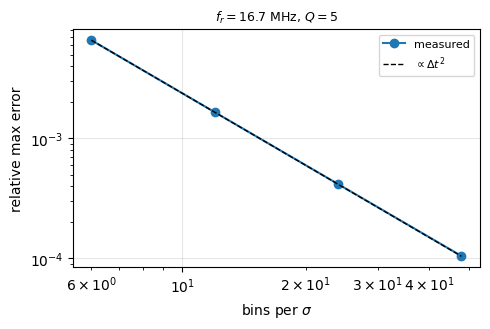

In [12]:
# Convergence order on a RESOLVED resonator (f_r below Nyquist at
# every binning tried): the residual shrinks as dt^2.
f_r_low, q_low = 0.2 / sigma, 5.0  # 16.7 MHz, Q = 5
omega_low = 2 * np.pi * f_r_low
alpha_low = omega_low / (2 * q_low)
omega_bar_low = np.sqrt(omega_low**2 - alpha_low**2)
pole_low = -alpha_low + 1j * omega_bar_low
rho_low = alpha_low * (1 + 1j * alpha_low / omega_bar_low)

binnings = np.array([6.0, 12.0, 24.0, 48.0])
errors = []
for bins_per_sigma_ in binnings:
    dt_ = sigma / bins_per_sigma_
    n_ = int(2 * round(10 * sigma / dt_ / 2))
    centre_ = n_ * dt_ / 2
    edges_ = np.arange(n_ + 1) * dt_
    cdf_ = 0.5 * (1 + erf((edges_ - centre_) / (sigma * np.sqrt(2))))
    q_ = np.diff(cdf_)
    v_model_ = near_far_voltage(q_, pole_low, rho_low, dt_)

    # spectral truth, as above; the periodic window is padded so the
    # ~ 95 ns ring-down dies out before it wraps around
    over_ = 200
    dt_f = dt_ / over_
    n_fft_ = 1 << int(np.ceil(np.log2((n_ * dt_ + 1.5e-6) / dt_f)))
    f_f = np.fft.rfftfreq(n_fft_, d=dt_f)
    lam_tilde_ = np.exp(-0.5 * (2 * np.pi * f_f * sigma) ** 2) * np.exp(
        -2j * np.pi * f_f * centre_
    )
    v_true_f = (
        np.fft.irfft(impedance(f_f, pole_low, rho_low) * lam_tilde_) / dt_f
    )
    v_true_ = v_true_f[np.arange(n_) * over_ + over_ // 2]

    errors.append(np.max(np.abs(v_model_ - v_true_)) / np.max(np.abs(v_true_)))

errors = np.array(errors)
slopes = -np.diff(np.log(errors)) / np.diff(np.log(binnings))
print("bins/sigma:", binnings)
print("relative max error:", errors)
print("pairwise convergence order:", np.round(slopes, 2))

fig, ax = plt.subplots(figsize=(5, 3.4))
ax.loglog(binnings, errors, "C0o-", label="measured")
ax.loglog(
    binnings,
    errors[0] * (binnings / binnings[0]) ** -2.0,
    "k--",
    lw=1,
    label=r"$\propto \Delta t^{2}$",
)
ax.set_xlabel(r"bins per $\sigma$")
ax.set_ylabel("relative max error")
ax.set_title(
    rf"$f_r = {f_r_low / 1e6:.1f}$ MHz, $Q = {q_low:.0f}$", fontsize=9
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Where each formula lives in BLonD

| this note | code |
|---|---|
| $p$, $\rho$ of a resonator (section 1) | `Resonators.get_vectorfit`, `Resonators._wake_bin_average` — `blond/physics/impedances/sources.py` |
| $B_2$ (2.2) | `quadratic_bspline` — `blond/physics/impedances/bin_average.py` |
| $\varphi_3$ (4.2), series form for $\lvert p\tau\rvert < 1$ | `causal_third_antiderivative_factor` — ibid. |
| far form (4.3) | `_smoothed_pole` — ibid. |
| hybrid $\overline W$ | `triple_box_average_pole(s)` — ibid.; exposed as `Resonators.get_wake_per_bin` |
| $Z_\mathrm{eff}$ (3.1), loss-factor numbers | docstrings of `bin_average.py` and `Resonators._wake_bin_average` (their weighting = table (b) of section 3, without the histogram sinc) |
| recursion (section 5) | `Specials.wake_from_pole_residue`, one implementation per backend; `STATE_LAG_BINS` — `blond/core/backends/backend.py` |
| $\rho_\mathrm{rec}$, state setup | `MultiPoleSparseSolve._setup_far_field_recursion` — `blond/physics/impedances/solvers.py` |
| three taps (section 6) | `MultiPoleSparseSolve._setup_near_field_kernel`, `_add_near_field_voltage` |
| turn-boundary / fractional-lag hand-over (section 7) | `MultiPoleSparseSolve._carry_previous_call`, `_trailing_tap`, `_inject_off_grid_carry` |

Not covered here, because it is bookkeeping on the same mathematics rather
than new mathematics: sparse profiles with gaps, the hand-over between calls
a fraction of a bin apart, and counter-rotating beams. The recursion state
is referenced by *time* (the emission clock), so all of these reduce to
choosing the right decay intervals and injection instants; the solver
docstrings in `solvers.py` spell them out.

The other time-domain solvers (`SingleTurnResonatorConvolutionSolver`,
`MultiPassResonatorSolver`, `ContinuousMultiTurnTimeDomainSolver`,
`TimeDomainFftSolver`) apply the same $\overline W$ by direct convolution,
which is why all of them — and the frequency-domain `PeriodicFreqSolver` —
agree on under-resolved resonators.